## Glassdoor Job Postings: Exploratory Data Analysis
This notebook examines advertised salary ranges and technical skills across data roles and industries. It aims to answer four questions:
1. How do advertised salary bounds differ by role?
2. Which industries offer the highest median salary?
3. Which technical skills are most in demand?
4. How does skill demand vary between different data roles?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

In [2]:
df = pd.read_csv("jobs_cleaned.csv")

In [3]:
role_counts = (
    df["job_title"]
    .value_counts()
    .rename_axis("job_title")
    .reset_index(name="job_count")
)

display(role_counts)

,job_title,job_count
0,Data Scientist,442
1,Other,87
2,Machine Learning Engineer,49
3,Data Analyst,47
4,Data Engineer,47


### 1. How do advertised salary bounds differ by role?

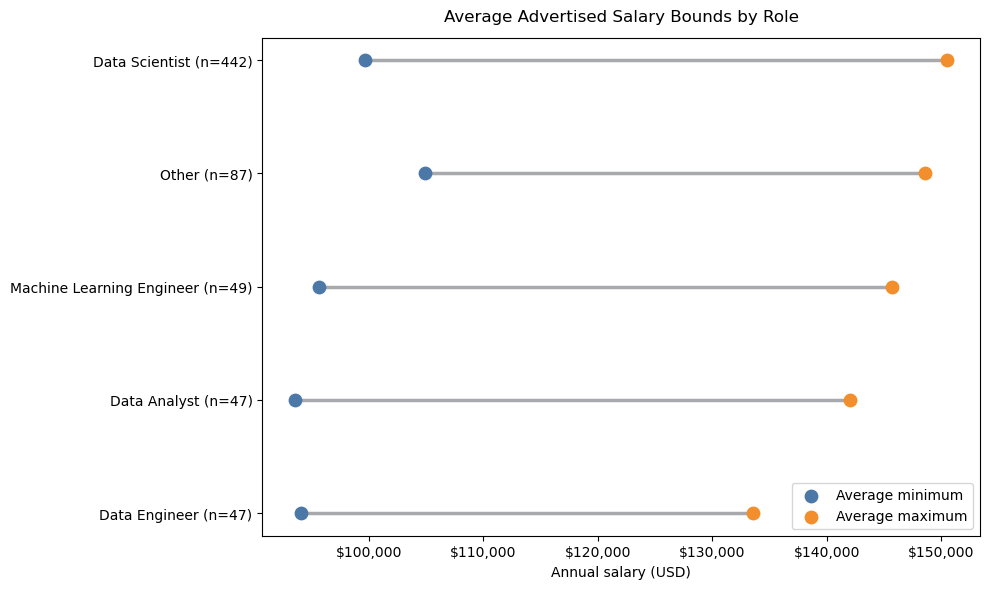

In [4]:
salary_by_role = (
    df.groupby("job_title", as_index=False)
    .agg(
        avg_min_salary=("min_salary", "mean"),
        avg_max_salary=("max_salary", "mean"),
        job_count=("job_title", "size"),
    )
    .sort_values("avg_max_salary", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = range(len(salary_by_role))

ax.hlines(
    y=y_positions,
    xmin=salary_by_role["avg_min_salary"],
    xmax=salary_by_role["avg_max_salary"],
    color="#A7A9AC",
    linewidth=2.5,
    zorder=1,
)

ax.scatter(
    salary_by_role["avg_min_salary"],
    y_positions,
    color="#4C78A8",
    label="Average minimum",
    s=80,
    zorder=2,
)
ax.scatter(
    salary_by_role["avg_max_salary"],
    y_positions,
    color="#F28E2B",
    label="Average maximum",
    s=80,
    zorder=2,
)

role_labels = [
    f"{row.job_title} (n={row.job_count})"
    for row in salary_by_role.itertuples()
]

ax.set_yticks(list(y_positions), labels=role_labels)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.set_title("Average Advertised Salary Bounds by Role", pad=12)
ax.set_xlabel("Annual salary (USD)")
ax.set_ylabel("")
ax.legend(loc="lower right", frameon=True)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### 2. Which industries offer the highest median salary?

,sector,industry,median_salary,job_count
0,Government,Federal Agencies,134750.0,16
1,Finance,Banks & Credit Unions,126750.0,8
2,Aerospace & Defense,Aerospace & Defense,123500.0,46
3,Business Services,Consulting,118000.0,38
4,Information Technology,Enterprise Software & Network Solutions,115500.0,43
5,Telecommunications,Telecommunications Services,115500.0,5
6,Business Services,Research & Development,114000.0,17
7,Health Care,Health Care Services & Hospitals,114000.0,21
8,Information Technology,Computer Hardware & Software,114000.0,57
9,"Oil, Gas, Energy & Utilities",Energy,114000.0,5


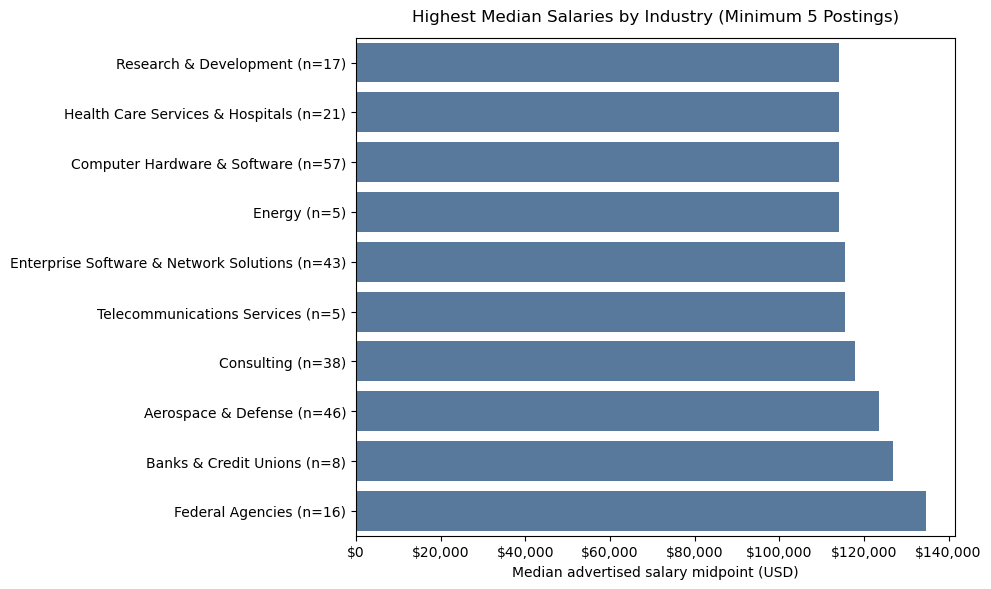

In [5]:
MIN_POSTINGS = 5

industry_salary = (
    df.loc[
        df["industry"].ne("Unknown") & df["sector"].ne("Unknown")
    ]
    .groupby(["sector", "industry"], as_index=False)
    .agg(
        median_salary=("avg_salary", "median"),
        job_count=("avg_salary", "size"),
    )
    .query("job_count >= @MIN_POSTINGS")
    .sort_values("median_salary", ascending=False)
    .head(10)
)

display(industry_salary.reset_index(drop=True))

industry_plot = industry_salary.sort_values("median_salary", ascending=True).copy()
industry_plot["industry_label"] = (
    industry_plot["industry"]
    + " (n="
    + industry_plot["job_count"].astype(str)
    + ")"
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=industry_plot,
    x="median_salary",
    y="industry_label",
    color="#4C78A8",
    ax=ax,
)

ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.set_title(
    f"Highest Median Salaries by Industry (Minimum {MIN_POSTINGS} Postings)",
    pad=12,
)
ax.set_xlabel("Median advertised salary midpoint (USD)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### 3. Which technical skills are most in demand?


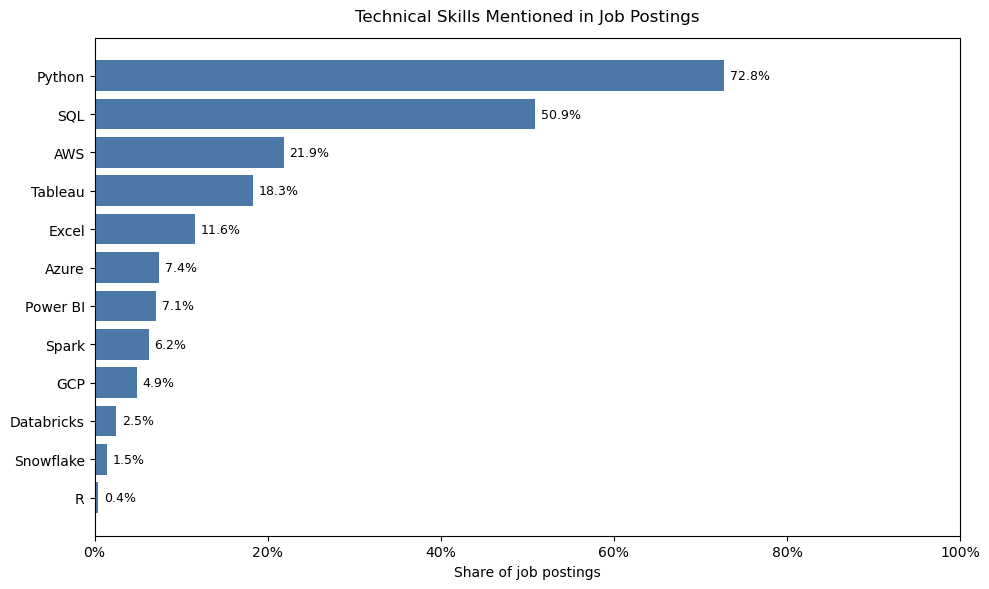

,skill,job_count,percentage
0,Python,489,72.767857
1,SQL,342,50.892857
2,AWS,147,21.875000
3,Tableau,123,18.303571
4,Excel,78,11.607143
5,Azure,50,7.440476
6,Power BI,48,7.142857
7,Spark,42,6.250000
8,GCP,33,4.910714
9,Databricks,17,2.529762


In [6]:
skill_labels = {
    "skill_sql": "SQL",
    "skill_python": "Python",
    "skill_excel": "Excel",
    "skill_power_bi": "Power BI",
    "skill_tableau": "Tableau",
    "skill_r": "R",
    "skill_aws": "AWS",
    "skill_azure": "Azure",
    "skill_gcp": "GCP",
    "skill_spark": "Spark",
    "skill_snowflake": "Snowflake",
    "skill_databricks": "Databricks",
}

skill_columns = list(skill_labels)
missing_skill_columns = set(skill_columns).difference(df.columns)
if missing_skill_columns:
    raise KeyError(f"Skill columns are missing: {sorted(missing_skill_columns)}")

skill_summary = (
    pd.DataFrame({
        "skill": [skill_labels[column] for column in skill_columns],
        "job_count": df[skill_columns].sum().to_numpy(),
        "percentage": df[skill_columns].mean().mul(100).to_numpy(),
    })
    .sort_values("percentage", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    skill_summary["skill"],
    skill_summary["percentage"],
    color="#4C78A8",
)

ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_xlim(0, max(100, skill_summary["percentage"].max() * 1.15))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_title("Technical Skills Mentioned in Job Postings", pad=12)
ax.set_xlabel("Share of job postings")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

display(skill_summary.sort_values("percentage", ascending=False).reset_index(drop=True))

### 4. How does skill demand vary between different data roles?

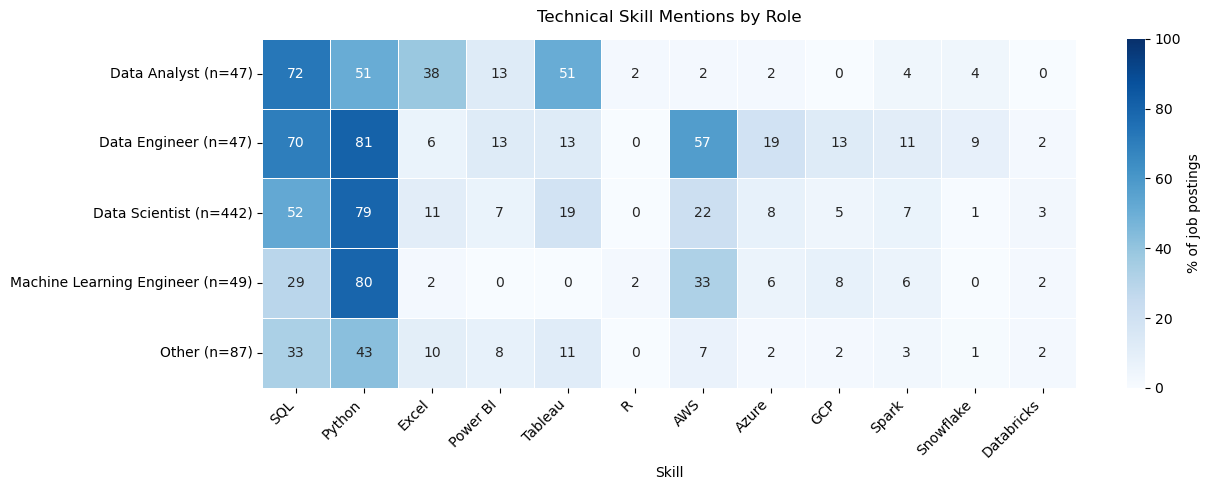

In [7]:
role_order = [
    "Data Analyst",
    "Data Engineer",
    "Data Scientist",
    "Machine Learning Engineer",
    "Other",
]
role_order = [role for role in role_order if role in df["job_title"].unique()]

skills_by_role = (
    df.groupby("job_title")[skill_columns]
    .mean()
    .mul(100)
    .reindex(role_order)
    .rename(columns=skill_labels)
)

role_count_lookup = df["job_title"].value_counts()
skills_by_role.index = [
    f"{role} (n={role_count_lookup[role]})"
    for role in skills_by_role.index
]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    skills_by_role,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "% of job postings"},
    ax=ax,
)

ax.set_title("Technical Skill Mentions by Role", pad=12)
ax.set_xlabel("Skill")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()